In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

driver_stats = pd.read_csv("../data/driver_stats_summary.csv") 

# Now the rest of the code will work because 'driver_stats' is defined!
X = driver_stats[['speed_mean', 'speed_max', 'speed_std', 'total_hard_brakes']]
y = driver_stats['avg_rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {len(X_train)} drivers, Testing on {len(X_test)} drivers.")

Training on 40 drivers, Testing on 10 drivers.


In [2]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("✅ Model trained and ready!")

✅ Model trained and ready!


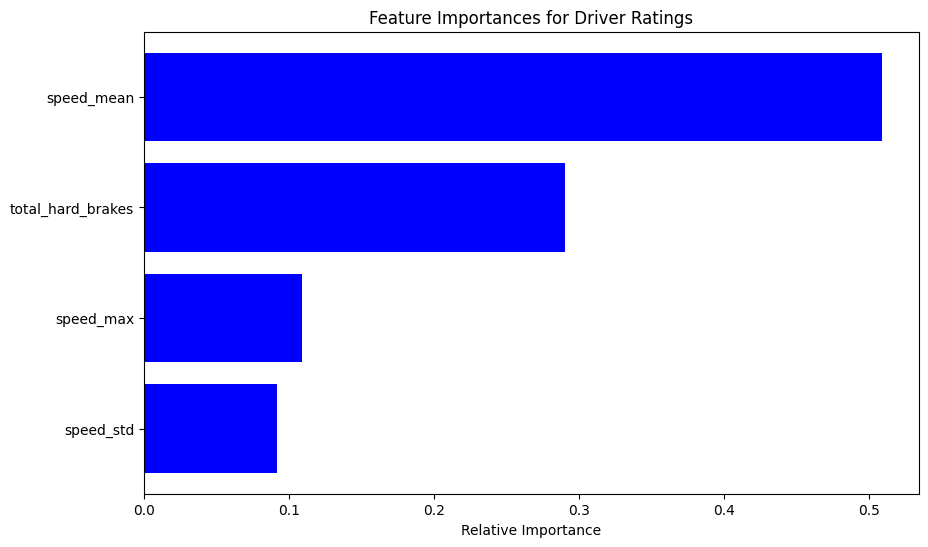

In [3]:
import numpy as np

importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Feature Importances for Driver Ratings')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()